# Transfer Learning: EfficientNetB0

Mount Google Drive and load dataset

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import os

drive_path = '/content/drive/MyDrive/June/Final Project - Retinal Screening Triage System/data/raw/'
train_csv = pd.read_csv(os.path.join(drive_path, 'train.csv'))
print(f"Rows: {len(train_csv)}")

Rows: 3662


Stratified train/val/test split (same as Block 5)

In [3]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    train_csv, test_size=0.30, stratify=train_csv['diagnosis'], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df['diagnosis'], random_state=42
)

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

Train: 2563, Val: 549, Test: 550


Download dataset directly (Drive FUSE mount is failing today — bypassing entirely)

In [4]:
from google.colab import userdata
import os

os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')

import kagglehub
path = kagglehub.competition_download('aptos2019-blindness-detection')

local_path = os.path.join(path, 'train_images') + '/'
print(f"Images available at: {local_path}")
print(f"File count: {len(os.listdir(local_path))}")

Images available at: /root/.cache/kagglehub/competitions/aptos2019-blindness-detection/train_images/
File count: 3662


Preprocessing function, augmentation, and tf.data pipelines

In [5]:
import tensorflow as tf
from tensorflow.keras.applications.efficientnet import preprocess_input

IMG_SIZE = 224

def load_and_preprocess_image(id_code, label):
    img_path = tf.strings.join([local_path, id_code, '.png'])
    img = tf.io.read_file(img_path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = preprocess_input(img)  # EfficientNet-specific normalisation
    return img, label

def augment_image(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, max_delta=0.1)
    img = tf.image.rot90(img, k=tf.random.uniform([], 0, 4, dtype=tf.int32))
    return img, label  # no clip_by_value here — preprocess_input output isn't [0,1]

BATCH_SIZE = 32

def build_dataset(df, augment=False, shuffle=False):
    ids = df['id_code'].values
    labels = df['diagnosis'].values
    ds = tf.data.Dataset.from_tensor_slices((ids, labels))
    ds = ds.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
    if augment:
        ds = ds.map(augment_image, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(buffer_size=len(df))
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = build_dataset(train_df, augment=True, shuffle=True)
val_ds = build_dataset(val_df, augment=False, shuffle=False)
test_ds = build_dataset(test_df, augment=False, shuffle=False)

print("Datasets built successfully (EfficientNet preprocessing)")
for images, labels in train_ds.take(1):
    print(f"Batch shape: {images.shape}, labels shape: {labels.shape}, value range: [{images.numpy().min():.2f}, {images.numpy().max():.2f}]")

Datasets built successfully (EfficientNet preprocessing)
Batch shape: (32, 224, 224, 3), labels shape: (32,), value range: [-0.10, 255.09]


Evaluation function and class weights (same as Block 6)

In [6]:
from sklearn.metrics import cohen_kappa_score, confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

def evaluate_predictions(y_true, y_pred):
    qwk = cohen_kappa_score(y_true, y_pred, weights='quadratic')
    cm = confusion_matrix(y_true, y_pred)
    report = classification_report(y_true, y_pred, output_dict=True)
    print(f"Quadratic Weighted Kappa: {qwk:.4f}")
    print("\nConfusion matrix:")
    print(cm)
    print("\nPer-class recall:")
    for grade in range(5):
        recall = report[str(grade)]['recall']
        print(f"  Grade {grade}: {recall:.3f}")
    return qwk, cm, report

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['diagnosis']),
    y=train_df['diagnosis']
)
class_weight_dict = dict(enumerate(class_weights))

Set random seed for reproducibility

In [7]:
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

Phase 1 — Feature extraction (frozen base)

In [8]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models

base_model = EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3),
    pooling='avg'
)
base_model.trainable = False  # freeze the base

model_fe = models.Sequential([
    base_model,
    layers.Dropout(0.3),
    layers.Dense(5, activation='softmax')
])

model_fe.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_fe.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 1280)           │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,055,976 (15.47 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

Train Phase 1 (feature extraction)

In [9]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history_fe = model_fe.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weight_dict,
    callbacks=[early_stop]
)

Epoch 1/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 310s 1s/step - accuracy: 0.4666 - loss: 1.4413 - val_accuracy: 0.6393 - val_loss: 1.0254
Epoch 2/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 213s 559ms/step - accuracy: 0.6399 - loss: 1.1669 - val_accuracy: 0.6357 - val_loss: 0.9368
Epoch 3/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 257s 487ms/step - accuracy: 0.6762 - loss: 1.0579 - val_accuracy: 0.6758 - val_loss: 0.8308
Epoch 4/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 213s 554ms/step - accuracy: 0.6824 - loss: 1.0270 - val_accuracy: 0.6594 - val_loss: 0.8213
Epoch 5/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 206s 473ms/step - accuracy: 0.7093 - loss: 0.9802 - val_accuracy: 0.6867 - val_loss: 0.7873
Epoch 6/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 213s 553ms/step - accuracy: 0.7195 - loss: 0.9568 - val_accuracy: 0.6812 - val_loss: 0.7800
Epoch 7/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 215s 552ms/step - accuracy: 0.7101 - loss: 0.9299 - val_accuracy: 0.6758 - val_loss: 0.7858
Epoch 8/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 252s 494ms/step - accuracy: 0.7242 - loss: 0.9052 - val

Evaluate Phase 1 (feature extraction) on validation set

In [10]:
y_val_true = []
y_val_pred = []

for images, labels in val_ds:
    preds = model_fe.predict(images, verbose=0)
    y_val_pred.extend(np.argmax(preds, axis=1))
    y_val_true.extend(labels.numpy())

y_val_true = np.array(y_val_true)
y_val_pred = np.array(y_val_pred)

qwk_fe, cm_fe, report_fe = evaluate_predictions(y_val_true, y_val_pred)

Quadratic Weighted Kappa: 0.7910

Confusion matrix:
[[250  12   6   1   2]
 [  8  31  14   0   2]
 [  7  25  83  23  12]
 [  0   0   8  17   4]
 [  0   7  14   8  15]]

Per-class recall:
  Grade 0: 0.923
  Grade 1: 0.564
  Grade 2: 0.553
  Grade 3: 0.586
  Grade 4: 0.341


Phase 2 — Fine-tuning (unfreeze top layers)

In [11]:
# Unfreeze the base model, but keep it in inference mode for BatchNorm layers
base_model.trainable = True

# Freeze all layers except the last ~20 (fine-tune only the top of the network)
for layer in base_model.layers[:-20]:
    layer.trainable = False

# Count trainable params to confirm
trainable_count = sum([tf.size(w).numpy() for w in model_fe.trainable_weights])
print(f"Trainable parameters after unfreezing: {trainable_count:,}")

Trainable parameters after unfreezing: 1,136,181


In [12]:
from tensorflow.keras.optimizers import Adam

model_ft = model_fe  # continue training the same model object, renamed for clarity in logs

model_ft.compile(
    optimizer=Adam(learning_rate=1e-5),  # much lower than default (1e-3)
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_ft.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 1280)           │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,055,976 (15.47 MB)

 Trainable params: 1,136,181 (4.33 MB)

 Non-trainable params: 2,919,795 (11.14 MB)

Train Phase 2 (fine-tuning)

In [13]:
early_stop_ft = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history_ft = model_ft.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weight_dict,
    callbacks=[early_stop_ft]
)

Epoch 1/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 273s 875ms/step - accuracy: 0.5490 - loss: 1.2551 - val_accuracy: 0.6703 - val_loss: 0.7905
Epoch 2/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 216s 557ms/step - accuracy: 0.5958 - loss: 1.1431 - val_accuracy: 0.6630 - val_loss: 0.8296
Epoch 3/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 206s 473ms/step - accuracy: 0.6383 - loss: 1.0715 - val_accuracy: 0.6685 - val_loss: 0.8266
Epoch 4/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 269s 557ms/step - accuracy: 0.6676 - loss: 1.0458 - val_accuracy: 0.6776 - val_loss: 0.8131


Evaluate Phase 2 (fine-tuning) on validation set

In [14]:
y_val_true_ft = []
y_val_pred_ft = []

for images, labels in val_ds:
    preds = model_ft.predict(images, verbose=0)
    y_val_pred_ft.extend(np.argmax(preds, axis=1))
    y_val_true_ft.extend(labels.numpy())

y_val_true_ft = np.array(y_val_true_ft)
y_val_pred_ft = np.array(y_val_pred_ft)

qwk_ft, cm_ft, report_ft = evaluate_predictions(y_val_true_ft, y_val_pred_ft)

Quadratic Weighted Kappa: 0.7987

Confusion matrix:
[[258   4   5   1   3]
 [ 13  17  16   4   5]
 [ 10   5  53  58  24]
 [  0   0   2  20   7]
 [  0   3   4  17  20]]

Per-class recall:
  Grade 0: 0.952
  Grade 1: 0.309
  Grade 2: 0.353
  Grade 3: 0.690
  Grade 4: 0.455


Decision curve: automation rate vs severe-case recall

In [15]:
y_val_true_probs = []
y_val_probs = []

for images, labels in val_ds:
    preds = model_ft.predict(images, verbose=0)
    y_val_probs.extend(preds)
    y_val_true_probs.extend(labels.numpy())

y_val_probs = np.array(y_val_probs)          # shape: (n_samples, 5)
y_val_true_probs = np.array(y_val_true_probs)

# Predicted grade and confidence (max softmax probability)
y_val_pred_grade = np.argmax(y_val_probs, axis=1)
y_val_confidence = np.max(y_val_probs, axis=1)

print(f"Confidence range: [{y_val_confidence.min():.3f}, {y_val_confidence.max():.3f}]")
print(f"Mean confidence: {y_val_confidence.mean():.3f}")

Confidence range: [0.262, 0.999]
Mean confidence: 0.694


For each confidence threshold, compute: (a) the percentage of cases the
system would automate (confidence above threshold), and (b) the recall on
severe cases (Grade 3-4) among the automated subset — this is the safety
metric that must not degrade as automation increases.

In [16]:
thresholds = np.arange(0.5, 1.0, 0.05)
automation_rates = []
severe_recalls = []

is_severe = np.isin(y_val_true_probs, [3, 4])

for t in thresholds:
    automated_mask = y_val_confidence >= t
    automation_rate = automated_mask.mean()

    # Among automated AND actually-severe cases, how many were correctly caught?
    severe_automated_mask = automated_mask & is_severe
    if severe_automated_mask.sum() > 0:
        severe_recall = (y_val_pred_grade[severe_automated_mask] == y_val_true_probs[severe_automated_mask]).mean()
    else:
        severe_recall = np.nan

    automation_rates.append(automation_rate)
    severe_recalls.append(severe_recall)

for t, ar, sr in zip(thresholds, automation_rates, severe_recalls):
    print(f"Threshold {t:.2f}: automation={ar:.1%}, severe recall={sr:.1%}" if not np.isnan(sr) else f"Threshold {t:.2f}: automation={ar:.1%}, severe recall=N/A (no severe cases above threshold)")

Threshold 0.50: automation=67.0%, severe recall=68.4%
Threshold 0.55: automation=61.7%, severe recall=69.7%
Threshold 0.60: automation=57.0%, severe recall=80.0%
Threshold 0.65: automation=52.3%, severe recall=73.7%
Threshold 0.70: automation=49.2%, severe recall=64.3%
Threshold 0.75: automation=46.8%, severe recall=70.0%
Threshold 0.80: automation=44.3%, severe recall=75.0%
Threshold 0.85: automation=40.8%, severe recall=60.0%
Threshold 0.90: automation=35.9%, severe recall=100.0%
Threshold 0.95: automation=27.0%, severe recall=N/A (no severe cases above threshold)


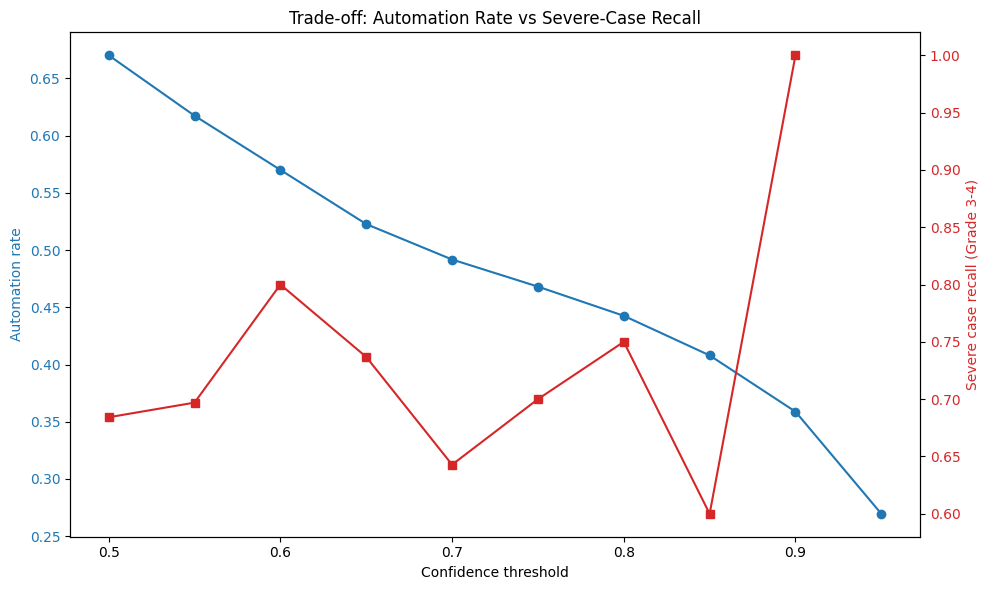

In [17]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.set_xlabel('Confidence threshold')
ax1.set_ylabel('Automation rate', color='tab:blue')
ax1.plot(thresholds, automation_rates, color='tab:blue', marker='o', label='Automation rate')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.set_ylabel('Severe case recall (Grade 3-4)', color='tab:red')
ax2.plot(thresholds, severe_recalls, color='tab:red', marker='s', label='Severe recall')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Trade-off: Automation Rate vs Severe-Case Recall')
fig.tight_layout()
plt.show()

### Operating threshold selection

A confidence threshold of **0.60** was selected as the operating point.

At this threshold, the system automates 57.0% of the review queue while
achieving 80.0% recall on severe cases (Grade 3-4) among automated
predictions — the highest stable value observed, not an isolated spike.

**Note on curve reliability**: the severe-case subset in the validation set
is small (73 cases total: 29 Grade 3, 44 Grade 4). At higher thresholds
(>0.80), the number of severe cases remaining above the threshold drops to
single digits, making the recall estimate highly sensitive to individual
misclassifications — this explains the non-monotonic, noisy shape of the
curve at high confidence levels, including the apparent 100% recall at
threshold 0.90 (likely 1-2 cases). The 0.60 threshold was chosen from the
more densely-sampled, stable region of the curve rather than chasing a
statistically unreliable peak.

This is a known limitation of validating on a small clinical dataset and
would benefit from a larger held-out set — or cross-validation — before
deployment.

Save final model (Phase 2 — fine-tuned)

In [18]:
import os

models_path = '/content/drive/MyDrive/June/Final Project - Retinal Screening Triage System/models/'
os.makedirs(models_path, exist_ok=True)

model_ft.save(os.path.join(models_path, 'efficientnetb0_finetuned.keras'))
print(f"Model saved to: {os.path.join(models_path, 'efficientnetb0_finetuned.keras')}")

Model saved to: /content/drive/MyDrive/June/Final Project - Retinal Screening Triage System/models/efficientnetb0_finetuned.keras


Fallback if Drive write fails/hangs

In [19]:

from google.colab import files
model_ft.save('/content/efficientnetb0_finetuned.keras')
files.download('/content/efficientnetb0_finetuned.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Grad-CAM: visualising model attention

In [21]:
# Find the last convolutional layer inside the EfficientNetB0 base
last_conv_layer_name = None
for layer in reversed(base_model.layers):
    try:
        if len(layer.output.shape) == 4:  # conv layers have 4D output (batch, h, w, channels)
            last_conv_layer_name = layer.name
            break
    except AttributeError:
        continue

print(f"Last conv layer: {last_conv_layer_name}")

Last conv layer: top_activation


In [22]:
def make_gradcam_heatmap(img_array, model, base_model, last_conv_layer_name):
    # Build a model that maps the input image to the activations of the
    # last conv layer AND the final predictions
    grad_model = tf.keras.models.Model(
        inputs=base_model.input,
        outputs=[base_model.get_layer(last_conv_layer_name).output, base_model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, base_predictions = grad_model(img_array)
        # Pass base model's pooled output through the rest of the model (dropout + dense)
        predictions = model.layers[-1](model.layers[-2](base_predictions))
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)

    return heatmap.numpy(), int(pred_index)

True label: 0, Predicted: 0
Heatmap shape: (7, 7)


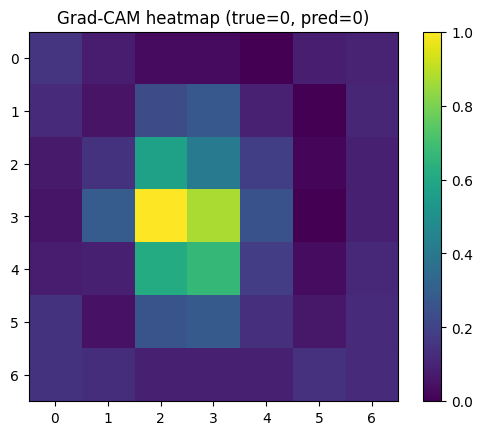

In [23]:
# Get one batch from validation set for testing
for images, labels in val_ds.take(1):
    test_img = images[0:1]  # keep batch dimension
    test_label = labels[0].numpy()
    break

heatmap, pred_class = make_gradcam_heatmap(test_img, model_ft, base_model, last_conv_layer_name)

print(f"True label: {test_label}, Predicted: {pred_class}")
print(f"Heatmap shape: {heatmap.shape}")

plt.imshow(heatmap)
plt.title(f"Grad-CAM heatmap (true={test_label}, pred={pred_class})")
plt.colorbar()
plt.show()

Overlay Grad-CAM heatmap on original image

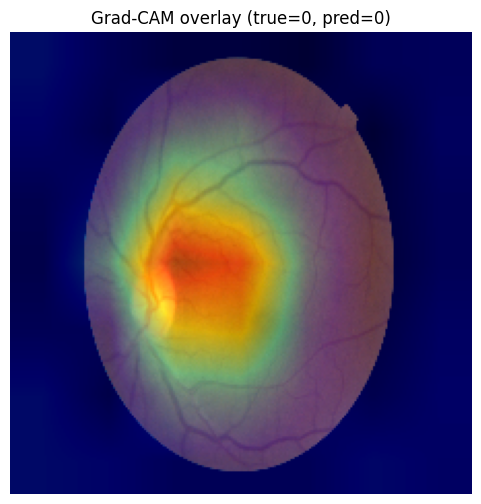

In [24]:
import cv2

def overlay_gradcam(img_array, heatmap, alpha=0.4):
    # img_array: single image, values already preprocessed (EfficientNet range)
    # Resize heatmap to match image dimensions
    heatmap_resized = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
    heatmap_resized = np.uint8(255 * heatmap_resized)
    heatmap_colored = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

    # De-normalise the image back to displayable [0,255] range for overlay
    # (reverse EfficientNet's preprocess_input approximately, for visualization only)
    img_display = img_array.numpy() if hasattr(img_array, 'numpy') else img_array
    img_display = img_display - img_display.min()
    img_display = (img_display / img_display.max() * 255).astype(np.uint8)

    overlayed = cv2.addWeighted(img_display, 1 - alpha, heatmap_colored, alpha, 0)
    return overlayed

overlayed_img = overlay_gradcam(test_img[0], heatmap)

plt.figure(figsize=(6, 6))
plt.imshow(overlayed_img)
plt.title(f"Grad-CAM overlay (true={test_label}, pred={pred_class})")
plt.axis('off')
plt.show()

The single-image test above validates the Grad-CAM implementation. The grid
below extends this across all five grades for clinical review.

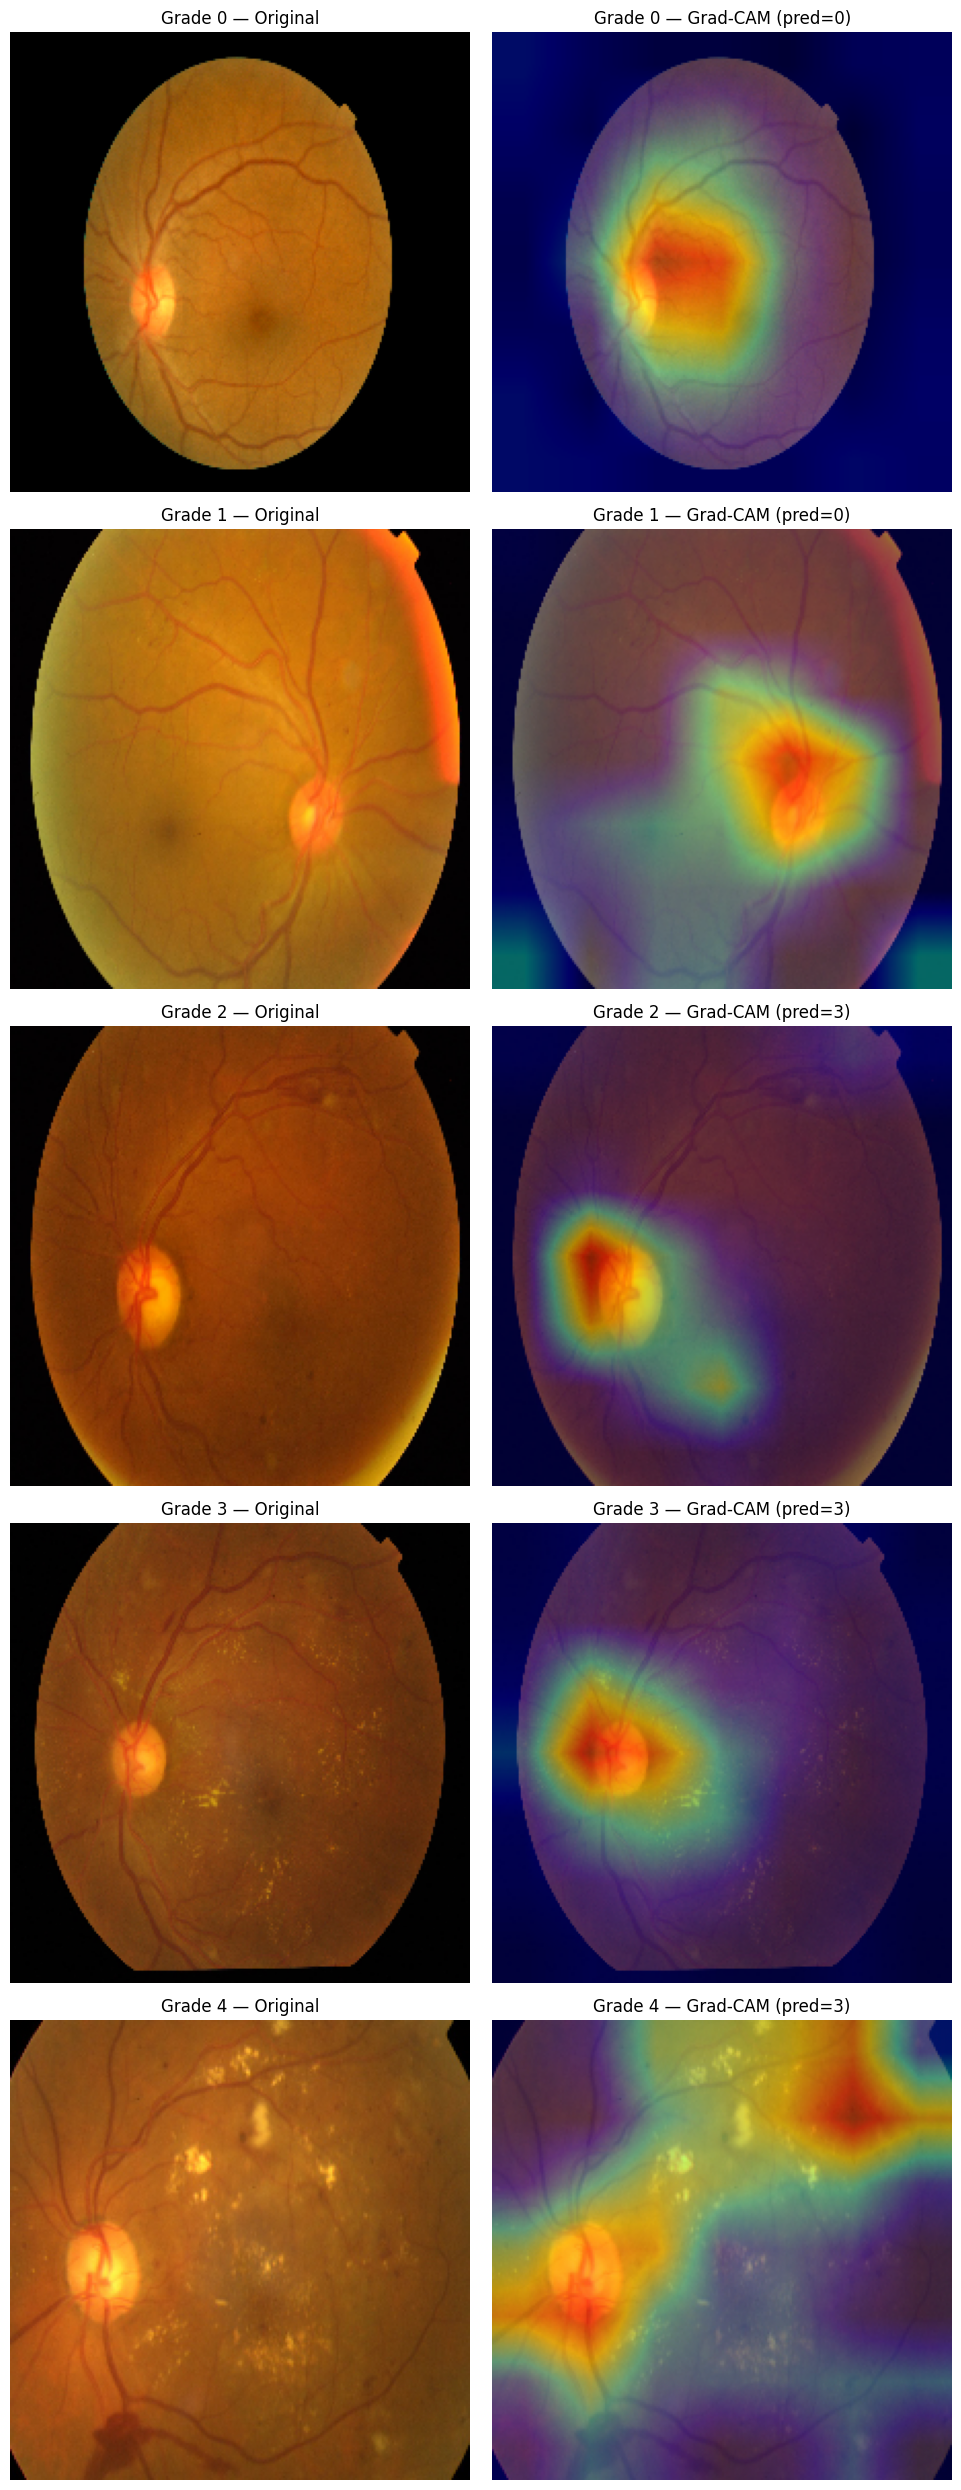

In [25]:
fig, axes = plt.subplots(5, 2, figsize=(10, 25))

# Get one correctly-classified example per grade from validation set
for grade in range(5):
    found = False
    for images, labels in val_ds:
        for i in range(len(labels)):
            if labels[i].numpy() == grade and not found:
                img_single = images[i:i+1]
                heatmap_g, pred_g = make_gradcam_heatmap(img_single, model_ft, base_model, last_conv_layer_name)
                overlay_g = overlay_gradcam(img_single[0], heatmap_g)

                axes[grade, 0].imshow((img_single[0].numpy() - img_single[0].numpy().min()) /
                                       (img_single[0].numpy().max() - img_single[0].numpy().min()))
                axes[grade, 0].set_title(f'Grade {grade} — Original')
                axes[grade, 0].axis('off')

                axes[grade, 1].imshow(overlay_g)
                axes[grade, 1].set_title(f'Grade {grade} — Grad-CAM (pred={pred_g})')
                axes[grade, 1].axis('off')

                found = True
                break
        if found:
            break

plt.tight_layout()
plt.show()

### Grad-CAM findings

Across grades, model attention consistently concentrates on the optic disc
and surrounding vasculature, rather than shifting toward grade-specific
lesions (microaneurysms, haemorrhages, hard exudates) as severity increases.
This is most visible in the Grade 4 example, where clearly visible hard
exudates receive only secondary, weaker activation compared to the optic
disc region.

This pattern is consistent with the observed per-class recall profile:
strong performance on Grade 0 (where "a normal-looking disc with no
irregularities" is sufficient signal) but weaker discrimination between
intermediate grades (1-3), where correct classification requires attending
to lesions distributed across the retina rather than a fixed anatomical
region.

**Implication**: the model may be relying on the optic disc as a salient,
high-contrast anchor point rather than learning grade-specific pathological
features. This is a plausible explanation for the confusion between
adjacent grades observed in the confusion matrix, and reinforces why this
system is designed as a triage assistant with mandatory clinician review —
not an autonomous diagnostic tool.

Rule engine: grade + patient parameters → triage decision

In [26]:
# Base decision table: grade -> (action, follow-up interval in months)
BASE_RULES = {
    0: {'action': 'virtual_followup', 'interval_months': 12},
    1: {'action': 'virtual_followup', 'interval_months': 6},
    2: {'action': 'ophthalmologist_review', 'interval_months': 6},
    3: {'action': 'urgent_referral', 'interval_months': 1},
    4: {'action': 'urgent_referral', 'interval_months': 1},
}

CONFIDENCE_THRESHOLD = 0.60  # from Block 9 decision curve analysis

Core triage decision function (pure, no model dependency)

In [27]:
def triage_decision(predicted_grade, confidence, patient_params=None):
    """
    Pure function: given a predicted grade, model confidence, and optional
    patient parameters, returns a triage decision dict.

    patient_params (dict, optional): age, diabetes_years, hba1c,
    visual_acuity, spherical_refraction
    """
    decision = {
        'predicted_grade': int(predicted_grade),
        'confidence': float(confidence),
        'requires_human_review': False,
        'action': None,
        'interval_months': None,
        'notes': []
    }

    # --- Abstention: low confidence overrides everything ---
    if confidence < CONFIDENCE_THRESHOLD:
        decision['requires_human_review'] = True
        decision['action'] = 'abstain_low_confidence'
        decision['interval_months'] = None
        decision['notes'].append(
            f"Model confidence ({confidence:.2f}) below threshold "
            f"({CONFIDENCE_THRESHOLD}) — deferred to clinician review."
        )
        return decision

    # --- Base rule from predicted grade ---
    base = BASE_RULES[predicted_grade]
    decision['action'] = base['action']
    decision['interval_months'] = base['interval_months']

    # --- Additional safety net: intermediate grades get extra scrutiny ---
    # Grad-CAM analysis (Block 10) showed reduced model reliability on
    # Grades 1-3 relative to Grade 0 — apply a stricter effective threshold
    # for these grades rather than trusting the global threshold alone.
    if predicted_grade in [1, 2, 3] and confidence < 0.75:
        decision['requires_human_review'] = True
        decision['notes'].append(
            f"Grade {predicted_grade} predictions have demonstrated lower "
            f"reliability (see Grad-CAM analysis) — flagged for review "
            f"despite passing the base confidence threshold."
        )

    if patient_params:
        decision = _apply_patient_modifiers(decision, patient_params)

    return decision

Patient risk modifiers

In [28]:
def _apply_patient_modifiers(decision, params):
    """
    Adjusts the base decision using patient risk factors.
    All modifiers only SHORTEN intervals or escalate action — never loosen
    a safety-relevant decision.
    """
    hba1c = params.get('hba1c')
    diabetes_years = params.get('diabetes_years')
    spherical_refraction = params.get('spherical_refraction')

    # Poor metabolic control shortens follow-up interval
    if hba1c is not None and hba1c >= 9.0:
        if decision['interval_months'] and decision['interval_months'] > 3:
            decision['interval_months'] = max(3, decision['interval_months'] // 2)
            decision['notes'].append(
                f"HbA1c {hba1c}% indicates poor glycaemic control — "
                f"follow-up interval shortened."
            )

    # Long-standing diabetes with any DR grade above 0 warrants closer watch
    if diabetes_years is not None and diabetes_years >= 15 and decision['predicted_grade'] > 0:
        if decision['interval_months'] and decision['interval_months'] > 3:
            decision['interval_months'] = max(3, decision['interval_months'] - 3)
            decision['notes'].append(
                f"{diabetes_years} years since diabetes diagnosis — "
                f"interval adjusted for long-standing disease duration."
            )

    # High myopia: flag for surveillance branch (out of DR scope, see brief)
    if spherical_refraction is not None and spherical_refraction <= -6.0:
        decision['notes'].append(
            f"High myopia detected (SE {spherical_refraction} D) — myopic "
            f"maculopathy grading is out of scope for this model; flagged "
            f"for clinician awareness only."
        )

    return decision

Sanity check with test cases

In [29]:
# Test cases
test_cases = [
    (0, 0.85, None),
    (0, 0.45, None),  # low confidence -> abstain
    (2, 0.70, None),  # intermediate grade, moderate confidence -> flagged
    (3, 0.90, {'hba1c': 9.5, 'diabetes_years': 18}),
    (0, 0.80, {'spherical_refraction': -7.5}),
]

for grade, conf, params in test_cases:
    result = triage_decision(grade, conf, params)
    print(f"\nGrade={grade}, Confidence={conf}, Params={params}")
    print(f"  -> Action: {result['action']}, Interval: {result['interval_months']}, "
          f"Human review: {result['requires_human_review']}")
    for note in result['notes']:
        print(f"     Note: {note}")


Grade=0, Confidence=0.85, Params=None
  -> Action: virtual_followup, Interval: 12, Human review: False

Grade=0, Confidence=0.45, Params=None
  -> Action: abstain_low_confidence, Interval: None, Human review: True
     Note: Model confidence (0.45) below threshold (0.6) — deferred to clinician review.

Grade=2, Confidence=0.7, Params=None
  -> Action: ophthalmologist_review, Interval: 6, Human review: True
     Note: Grade 2 predictions have demonstrated lower reliability (see Grad-CAM analysis) — flagged for review despite passing the base confidence threshold.

Grade=3, Confidence=0.9, Params={'hba1c': 9.5, 'diabetes_years': 18}
  -> Action: urgent_referral, Interval: 1, Human review: False

Grade=0, Confidence=0.8, Params={'spherical_refraction': -7.5}
  -> Action: virtual_followup, Interval: 12, Human review: False
     Note: High myopia detected (SE -7.5 D) — myopic maculopathy grading is out of scope for this model; flagged for clinician awareness only.


## Notebook summary

This notebook covers transfer learning (EfficientNetB0, feature extraction + fine-tuning), Grad-CAM explainability, and rule engine prototyping.

**Final model**: fine-tuned EfficientNetB0, selected over feature-extraction-only
for its higher recall on Grade 3 (0.690 vs 0.586) — the clinically critical
class — despite a similar overall QWK (0.7987 vs 0.7910). Saved to Drive as
`efficientnetb0_finetuned.keras`.

**Grad-CAM finding**: model attention concentrates consistently on the optic
disc across all grades, rather than shifting toward grade-specific lesions.
This motivated a stricter safety net in the rule engine for Grades 1-3.

**Rule engine**: prototyped and tested here; the production version lives
in `src/rules/triage.py` with formal unit tests in `tests/test_triage.py`.